# Preprocessing — Projet Alzheimer

**Objectif** : Préparer les données brutes pour la modélisation ML  
**Dataset** : ADNI — table ALZ_BRONZE  
**Corrections** : split train/test avant imputation pour éviter la fuite de données

## 1. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from supabase import create_client
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

## 2. Paramètres

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 3. Chargement des données

In [3]:
url = os.environ.get("SUPABASE_URL")
key = os.environ.get("SUPABASE_SERVICE_ROLE_KEY")
supabase = create_client(url, key)

batch_size = 1000
start = 0
rows = []

while True:
    end = start + batch_size - 1
    batch = supabase.table("ALZ_BRONZE").select("*").range(start, end).execute()
    if not batch.data:
        break
    rows.extend(batch.data)
    start += batch_size

df = pd.DataFrame(rows)
print("Données chargées :", df.shape[0], "lignes,", df.shape[1], "colonnes")

Données chargées : 15987 lignes, 584 colonnes


## 4. Filtre recommandé par ADNI

In [4]:
nb_avant = len(df)
df = df[~df["PTID"].str.startswith("381_S_10", na=False)]
print("Lignes supprimées (filtre ADNI) :", nb_avant - len(df))
print("Lignes restantes :", len(df))

Lignes supprimées (filtre ADNI) : 135
Lignes restantes : 15852


## 5. Remplacement des codes manquants ADNI

In [5]:
# ADNI utilise -4, -1 et 9999 à la place de NaN
nb_nan_avant = df.isnull().sum().sum()
df = df.replace([-4, -1, 9999], np.nan)
nb_nan_apres = df.isnull().sum().sum()
print("Valeurs manquantes ajoutées :", nb_nan_apres - nb_nan_avant)

Valeurs manquantes ajoutées : 84415


## 6. Transformation de la variable cible

On regroupe en 2 classes : **0 = Sain (CN)** / **1 = À risque (MCI + AD)**

In [6]:
df["DIAGNOSIS"] = df["DIAGNOSIS"].replace({1: 0, 2: 1, 3: 1})
print("Distribution de la cible :")
print(df["DIAGNOSIS"].value_counts())

Distribution de la cible :
DIAGNOSIS
1    9499
0    6353
Name: count, dtype: int64


## 7. Conversion des unités poids / taille

In [7]:
# Poids : livres (VSWTUNIT == 1) → kilogrammes
df.loc[df["VSWTUNIT"] == 1, "VSWEIGHT"] = (df.loc[df["VSWTUNIT"] == 1, "VSWEIGHT"] / 2.20462).round(0)
print("Poids moyen :", round(df["VSWEIGHT"].mean(), 1), "kg")

# Taille : pouces (VSHTUNIT == 1) → centimètres
df.loc[df["VSHTUNIT"] == 1, "VSHEIGHT"] = (df.loc[df["VSHTUNIT"] == 1, "VSHEIGHT"] * 2.54).round(0)
print("Taille moyenne :", round(df["VSHEIGHT"].mean(), 1), "cm")

# Supprimer les lignes où la valeur existe mais l'unité est manquante
nb_avant = len(df)
df = df[~((df["VSHEIGHT"].notna()) & (df["VSHTUNIT"].isna()))]
df = df[~((df["VSWEIGHT"].notna()) & (df["VSWTUNIT"].isna()))]
print("Lignes supprimées (unité manquante) :", nb_avant - len(df))

Poids moyen : 77.1 kg
Taille moyenne : 168.8 cm
Lignes supprimées (unité manquante) : 5


## 8. Sélection des variables — étape 1 (choix métier)

On retient 34 variables pertinentes selon la littérature médicale ADNI.

In [8]:
cols = [
    'DIAGNOSIS', 'PTGENDER', 'PTEDUCAT', 'PTMARRY', 'PTHAND',
    'MMSCORE', 'CDRSB', 'CDGLOBAL', 'CDMEMORY', 'CDJUDGE',
    'CDCOMMUN', 'CDHOME', 'CDCARE', 'TOTSCORE', 'TOTAL13',
    'WORD2DL', 'WORD1DL', 'VSWEIGHT', 'VSHEIGHT', 'VSBPSYS',
    'VSBPDIA', 'VSPULSE', 'ST101SV', 'ST112SV', 'ST120SV', 'ST125SV',
    'MH4CARD', 'MH9ENDO', 'MH14ALCH', 'MH16SMOK', 'MH2NEURL',
    'MHPSYCH', 'MH11HEMA', 'MH6HEPAT'
]

df = df[cols]
print("Variables sélectionnées :", df.shape[1])

Variables sélectionnées : 34


## 9. Suppression des doublons

In [9]:
nb_avant = len(df)
df = df.drop_duplicates()
print("Doublons supprimés :", nb_avant - len(df))
print("Lignes restantes :", len(df))

Doublons supprimés : 312
Lignes restantes : 15535


## 10. Feature engineering

Création de 3 nouvelles variables à partir des données existantes.

In [10]:
# Indice de masse corporelle
df['IMC'] = df['VSWEIGHT'] / ((df['VSHEIGHT'] / 100) ** 2)
print("IMC moyen :", round(df['IMC'].mean(), 1))

# Ratio tension artérielle (systolique / diastolique)
df['RtensionA'] = df['VSBPSYS'] / df['VSBPDIA']
print("Ratio tension moyen :", round(df['RtensionA'].mean(), 2))

# Pression pulsée (systolique - diastolique)
df['pressionP'] = df['VSBPSYS'] - df['VSBPDIA']
print("Pression pulsée moyenne :", round(df['pressionP'].mean(), 1))

IMC moyen : 27.9
Ratio tension moyen : 1.82
Pression pulsée moyenne : 59.6


## 11. Découpage train / test (80/20)

Split avant imputation et la normalisation pour éviter la fuite de données vers le jeu de test.

In [11]:
X = df.drop(columns=['DIAGNOSIS'])
y = df['DIAGNOSIS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Copie pour éviter les avertissements pandas
X_train = X_train.copy()
X_test = X_test.copy()

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print()
print("Distribution de la cible (train) :")
print(y_train.value_counts())

X_train : (12428, 36)
X_test  : (3107, 36)

Distribution de la cible (train) :
DIAGNOSIS
1    7582
0    4846
Name: count, dtype: int64


## 12. Imputation des valeurs manquantes

On entraîne l'imputeur sur le train uniquement, puis on l'applique sur train et test.

In [12]:
numeric_cols = [
    'PTEDUCAT', 'MMSCORE', 'CDRSB', 'CDGLOBAL', 'CDMEMORY', 'CDJUDGE',
    'CDCOMMUN', 'CDHOME', 'CDCARE', 'TOTSCORE', 'TOTAL13',
    'VSWEIGHT', 'VSHEIGHT', 'VSBPSYS', 'VSBPDIA', 'VSPULSE',
    'ST101SV', 'ST112SV', 'ST120SV', 'ST125SV',
    'IMC', 'RtensionA', 'pressionP'
]

categorical_cols = [
    'PTGENDER', 'PTMARRY', 'PTHAND',
    'WORD2DL', 'WORD1DL', 'MH4CARD', 'MH9ENDO', 'MH14ALCH',
    'MH16SMOK', 'MH2NEURL', 'MHPSYCH', 'MH11HEMA', 'MH6HEPAT'
]

# Médiane pour les numériques
imputer_num = SimpleImputer(strategy='median')
X_train[numeric_cols] = imputer_num.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = imputer_num.transform(X_test[numeric_cols])

# Mode pour les catégorielles
imputer_cat = SimpleImputer(strategy='most_frequent')
X_train[categorical_cols] = imputer_cat.fit_transform(X_train[categorical_cols])
X_test[categorical_cols]  = imputer_cat.transform(X_test[categorical_cols])

print("Valeurs manquantes dans X_train :", X_train.isnull().sum().sum())
print("Valeurs manquantes dans X_test  :", X_test.isnull().sum().sum())

Valeurs manquantes dans X_train : 0
Valeurs manquantes dans X_test  : 0


## 13. Encodage des variables catégorielles

OneHotEncoder pour les variables nominales (genre, statut marital, main dominante).

In [13]:
nominal_cols = ['PTGENDER', 'PTMARRY', 'PTHAND']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
encoded_train = encoder.fit_transform(X_train[nominal_cols])
encoded_test  = encoder.transform(X_test[nominal_cols])

encoded_col_names = encoder.get_feature_names_out(nominal_cols)

df_enc_train = pd.DataFrame(encoded_train, columns=encoded_col_names, index=X_train.index)
df_enc_test  = pd.DataFrame(encoded_test,  columns=encoded_col_names, index=X_test.index)

X_train = X_train.drop(columns=nominal_cols)
X_test  = X_test.drop(columns=nominal_cols)

X_train = pd.concat([X_train, df_enc_train], axis=1)
X_test  = pd.concat([X_test,  df_enc_test],  axis=1)

print("Variables après encodage :", X_train.shape[1])

Variables après encodage : 40


## 14. Normalisation (StandardScaler)

On entraîne le scaler sur le train uniquement, puis on l'applique sur train et test.

In [14]:
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print("Normalisation appliquée sur", len(numeric_cols), "variables")
print("Moyenne (train, doit être ≈ 0) :", round(X_train[numeric_cols].mean().mean(), 4))

Normalisation appliquée sur 23 variables
Moyenne (train, doit être ≈ 0) : 0.0


## 15. Sélection des variables — étape 2 (Random Forest)

On entraîne un Random Forest sur le train pour identifier les variables les plus utiles.

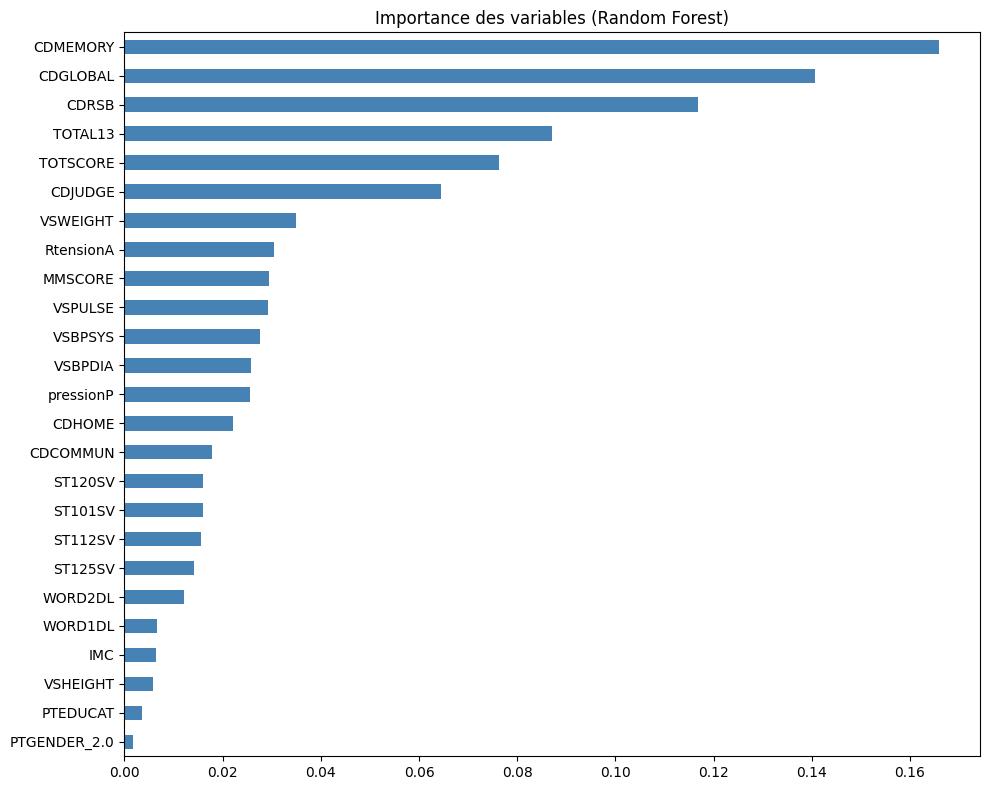

In [15]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

importances = pd.Series(model_rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(25).plot(kind='barh', color='steelblue')
plt.title("Importance des variables (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
# On garde les 21 variables les plus importantes
cols_final = [
    "CDGLOBAL", "CDMEMORY", "CDRSB", "TOTSCORE", "TOTAL13", "CDJUDGE",
    "MMSCORE", "VSWEIGHT", "RtensionA", "VSPULSE", "CDHOME", "VSBPSYS",
    "pressionP", "CDCOMMUN", "VSBPDIA", "ST112SV", "ST120SV", "ST101SV",
    "ST125SV", "WORD2DL", "IMC"
]

X_train = X_train[cols_final]
X_test  = X_test[cols_final]

print("Variables finales :", X_train.shape[1])
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

Variables finales : 21
X_train : (12428, 21)
X_test  : (3107, 21)


## 16. Résumé du preprocessing

In [17]:
print("=== RÉSUMÉ DU PREPROCESSING ===")
print()
print("Données brutes        : 15 987 lignes × 584 colonnes")
print("Données finales       :", X_train.shape[0] + X_test.shape[0], "lignes ×", X_train.shape[1], "colonnes")
print()
print("Étapes appliquées :")
print("  1. Filtre ADNI (135 lignes supprimées)")
print("  2. Codes manquants -4, -1, 9999 → NaN")
print("  3. Cible : CN → 0, MCI + AD → 1")
print("  4. Conversion poids (livres → kg) et taille (pouces → cm)")
print("  5. Sélection de 34 variables (choix métier)")
print("  6. Suppression des doublons")
print("  7. Feature engineering : IMC, RtensionA, pressionP")
print("  8. Split train/test 80/20 stratifié")
print("  9. Imputation médiane (numérique) et mode (catégoriel)")
print(" 10. Encodage OneHotEncoder")
print(" 11. Normalisation StandardScaler")
print(" 12. Sélection finale :", X_train.shape[1], "variables")
print()
print("Train :", X_train.shape[0], "lignes")
print("Test  :", X_test.shape[0], "lignes")
print()
print("Distribution cible (train) :")
print(y_train.value_counts())

=== RÉSUMÉ DU PREPROCESSING ===

Données brutes        : 15 987 lignes × 584 colonnes
Données finales       : 15535 lignes × 21 colonnes

Étapes appliquées :
  1. Filtre ADNI (135 lignes supprimées)
  2. Codes manquants -4, -1, 9999 → NaN
  3. Cible : CN → 0, MCI + AD → 1
  4. Conversion poids (livres → kg) et taille (pouces → cm)
  5. Sélection de 34 variables (choix métier)
  6. Suppression des doublons
  7. Feature engineering : IMC, RtensionA, pressionP
  8. Split train/test 80/20 stratifié
  9. Imputation médiane (numérique) et mode (catégoriel)
 10. Encodage OneHotEncoder
 11. Normalisation StandardScaler
 12. Sélection finale : 21 variables

Train : 12428 lignes
Test  : 3107 lignes

Distribution cible (train) :
DIAGNOSIS
1    7582
0    4846
Name: count, dtype: int64


## 17. Sauvegarde des tables sur Supabase

In [18]:
def save_to_supabase(data, table_name, batch_size=2000):
    if isinstance(data, pd.Series):
        data = data.to_frame()
    col = data.columns[0]
    supabase.table(table_name).delete().gte(col, -999999999).execute()
    records = data.to_dict(orient="records")
    for i in range(0, len(records), batch_size):
        batch = records[i:i + batch_size]
        supabase.table(table_name).insert(batch).execute()
        print("Inséré", i + len(batch), "/", len(records), "lignes")
    print("Table", table_name, "sauvegardée :", data.shape)

save_to_supabase(X_train, "X_train")
save_to_supabase(X_test,  "X_test")
save_to_supabase(y_train, "y_train")
save_to_supabase(y_test,  "y_test")

Inséré 2000 / 12428 lignes
Inséré 4000 / 12428 lignes
Inséré 6000 / 12428 lignes
Inséré 8000 / 12428 lignes
Inséré 10000 / 12428 lignes
Inséré 12000 / 12428 lignes
Inséré 12428 / 12428 lignes
Table X_train sauvegardée : (12428, 21)
Inséré 2000 / 3107 lignes
Inséré 3107 / 3107 lignes
Table X_test sauvegardée : (3107, 21)
Inséré 2000 / 12428 lignes
Inséré 4000 / 12428 lignes
Inséré 6000 / 12428 lignes
Inséré 8000 / 12428 lignes
Inséré 10000 / 12428 lignes
Inséré 12000 / 12428 lignes
Inséré 12428 / 12428 lignes
Table y_train sauvegardée : (12428, 1)
Inséré 2000 / 3107 lignes
Inséré 3107 / 3107 lignes
Table y_test sauvegardée : (3107, 1)


## 18. Sauvegarde des transformateurs

In [19]:
os.makedirs("transformers", exist_ok=True)

transformers = {
    'imputer_num': imputer_num,
    'imputer_cat': imputer_cat,
    'scaler': scaler,
    'encoder': encoder,
    'feature_names': cols_final
}

with open('transformers/transformers.pkl', 'wb') as f:
    pickle.dump(transformers, f)

print("Transformateurs sauvegardés : transformers/transformers.pkl")

Transformateurs sauvegardés : transformers/transformers.pkl
